<a href="https://colab.research.google.com/github/seap-udea/fargopy/blob/main/Murillo_Zuluaga_Montesinos_PDS70c_CodeSnippets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Three-dimensional circumplanetary flows in a PDS 70c-inspired system: hydrodynamic simulations with FARGO3D and analysis with FARGOpy
## Codesnippets in paper

In [1]:
!pip install -Uq fargopy
import fargopy as fp
fp.__version__

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 74.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.0/519.0 kB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 90.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 79.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 MB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 19.0 MB/s eta 0:00:00
Configuring FARGOpy for the first time
Running FARGOpy version 1.2.1.
NOTE: Since alpha versions (<=0.X.X) a major refactor has been done in versions 1.1.X.
Please check the documentation for more information.


'1.2.1'

## Code snippet 1

Downloading...
From: https://docs.google.com/uc?export=download&id=1Xzgk9qatZPNX8mLmB58R9NIi_YQUrHz9
To: /tmp/p3disoj.tgz
100%|██████████| 84.2M/84.2M [00:01<00:00, 55.1MB/s]


Uncompressing p3disoj.tgz into /tmp/p3disoj
Done.
FARGO3D directory '/root/fargo3d/' does not exist.
Now you are connected with output directory '/tmp/p3disoj'
Found a variables.par file in '/tmp/p3disoj', loading properties
Loading variables
85 variables loaded
Simulation in 3 dimensions
Loading domain in spherical coordinates:
	Variable phi: 128 [[0, np.float64(-3.117048960983623)], [-1, np.float64(3.117048960983623)]]
	Variable r: 64 [[0, np.float64(0.5078125)], [-1, np.float64(1.4921875)]]
	Variable theta: 32 [[0, np.float64(1.4231400767948967)], [-1, np.float64(1.5684525767948965)]]
Number of snapshots in output directory: 11
Planets found in summary.dat
  Name: Jupiter, Initial pos: [1.0, 0.001, 0.0], Mass: 0.001
Units set to CGS.


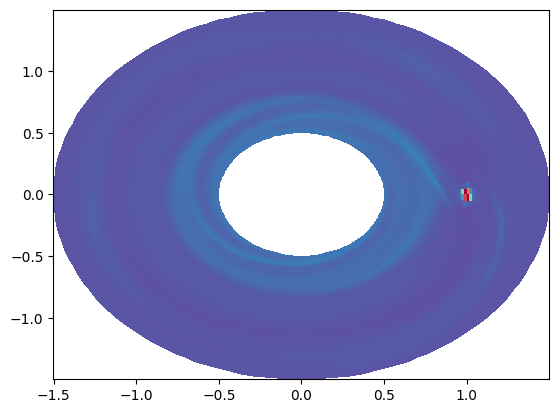

In [5]:
# Tested in versions 1.2.X of FARGOpy
import fargopy as fp
import numpy as np
import matplotlib.pyplot as plt

path = fp.Simulation.download_precomputed('p3disoj')
sim = fp.Simulation(output_dir=path)
sim.units("CGS")

fields_cartesian = sim.load_field(
    fields='gasdens',
    snapshot=[1, 10],
    coords='cartesian',
    slice='theta=1.567'
)

snapshot = 9
x = fields_cartesian.var1_mesh[snapshot]
y = fields_cartesian.var2_mesh[snapshot]

gasdens_plane = fields_cartesian.gasdens_mesh[snapshot]

plt.pcolormesh(x, y, gasdens_plane, cmap='Spectral_r')

## Code snippet 2

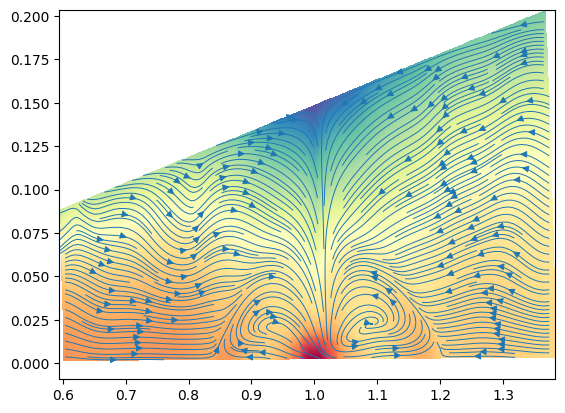

In [6]:
fields = sim.load_field(
    fields=['gasv','gasdens'],
    slice="r=[0.6,1.4], phi=0",
    snapshot=9
)
# Create the mesh grid for interpolation
X, Z = np.meshgrid(
    np.linspace(fields.var1_mesh[0].min(),
                 fields.var1_mesh[0].max(), 720),
    np.linspace(fields.var3_mesh[0].min(),
                 fields.var3_mesh[0].max(), 720)
)
# Interpolate
gasdens_interp = fields.evaluate(
    field='gasdens', time=0, var1=X, var3=Z
)
velocity_interp = fields.evaluate(
    field='gasv', time=0, var1=X, var3=Z
)

# Colormesh of density
plt.pcolormesh(
    X, Z, np.log10(gasdens_interp),
    cmap='Spectral_r'
)
# Streamlines of velocity
plt.streamplot(
    X, Z,
    velocity_interp[0], velocity_interp[2],
    linewidth=0.7, density=3.0
)

## Code snippet 3

In [7]:
simpath = fp.Simulation.download_precomputed('p3disoj')
sim = fp.Simulation(output_dir=simpath)

# Load planet properties
planet = sim.load_planets(snapshot=10)[0]

# Define spherical surface at the Hill radius
sphere = fp.Surface(
    type="sphere",
    center=(planet.pos.x, planet.pos.y, planet.pos.z),
    radius=planet.hill_radius,
    subdivisions=6,
    z_cut=0.0
)

# Compute enclosed gas mass
mass = sphere.total_mass(
    sim,
    snapshot=[0,10],
    follow_planet=True
)

# Compute accretion rate
flux = sphere.mass_flux(
    sim=sim,
    snapshot=[0,10],
    follow_planet=True
)

Precomputed output directory '/tmp/p3disoj' already exist
FARGO3D directory '/root/fargo3d/' does not exist.
Now you are connected with output directory '/tmp/p3disoj'
Found a variables.par file in '/tmp/p3disoj', loading properties
Loading variables
85 variables loaded
Simulation in 3 dimensions
Loading domain in spherical coordinates:
	Variable phi: 128 [[0, np.float64(-3.117048960983623)], [-1, np.float64(3.117048960983623)]]
	Variable r: 64 [[0, np.float64(0.5078125)], [-1, np.float64(1.4921875)]]
	Variable theta: 32 [[0, np.float64(1.4231400767948967)], [-1, np.float64(1.5684525767948965)]]
Number of snapshots in output directory: 11
Planets found in summary.dat
  Name: Jupiter, Initial pos: [1.0, 0.001, 0.0], Mass: 0.001


Calculating mass flux: 100%|██████████| 11/11 [02:40<00:00, 14.62s/it]
